# Przewidywanie cen mieszkań na podstawie cech nieruchomości
Opis: Model uczenia maszynowego przewidujący cenę mieszkania na podstawie liczby
pokoi, metrażu, lokalizacji itp.

Used dataset: **Ames Housing Dataset**

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import os

if(not os.path.isdir('data')):
    path = kagglehub.dataset_download("shashanknecrothapa/ames-housing-dataset", output_dir='./data')
    print("Path to dataset:", path)

df = pd.read_csv('./data/AmesHousing.csv')

print(df.shape)  # (2930, 82)
df.head()

(2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


# Przygotowanie danych

* Obsługa braków w danych
* Zamiana Stringów
* Usuwanie outliersów (Z-score, IQR method, visually)
* Standaryzacja (StandardScaler)
* Numeric skew transforms (log1p)

In [2]:
df.drop(columns=['Order', 'PID', 'Garage Yr Blt', 'Mo Sold', 'Condition 2', 'Roof Matl', 'Heating'], inplace=True)

In [3]:
# Fill categorical "absent" columns with 'None'
none_cols = [ 'Alley', 'Mas Vnr Type', 'Bsmt Qual', 'Bsmt Cond',
                'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2',
                'Fireplace Qu', 'Garage Type', 'Garage Finish',
                'Garage Qual', 'Garage Cond', 'Pool QC', 'Fence', 'Misc Feature'
]
df[none_cols] = df[none_cols].fillna('None')

# Fill numeric absent columns with 0
zero_cols = [ 'Lot Frontage', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2',
                'Bsmt Unf SF', 'Total Bsmt SF', 'Bsmt Full Bath', 'Bsmt Half Bath',
                'Garage Cars', 'Garage Area'
]
df[zero_cols] = df[zero_cols].fillna(0)

df['Electrical'] = df['Electrical'].fillna('SBrkr')

In [4]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['SalePrice'])
y = df['SalePrice']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, TargetEncoder

ordinal_cols = {
    'Lot Shape':        ['IR3', 'IR2', 'IR1', 'Reg'],
    'Utilities':        ['ELO', 'NoSeWa', 'NoSewr', 'AllPub'],
    'Land Slope':       ['Gtl', 'Mod', 'Sev'],
    'Exter Qual':       ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Exter Cond':       ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Bsmt Qual':        ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Bsmt Cond':        ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Bsmt Exposure':    ['None', 'No', 'Mn', 'Av', 'Gd'],
    'BsmtFin Type 1':   ['None', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
    'BsmtFin Type 2':   ['None', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
    'Central Air':      ['N', 'Y'],
    'Electrical':       ['Mix', 'FuseP', 'FuseF', 'FuseA', 'SBrkr'],
    'Kitchen Qual':     ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Functional':       ['Sal', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ'],
    'Fireplace Qu':     ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Garage Finish':    ['None', 'Unf', 'RFn', 'Fin'],
    'Garage Qual':      ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Garage Cond':      ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Paved Drive':      ['N', 'P', 'Y'],
    'Pool QC':          ['None', 'Fa', 'TA', 'Gd', 'Ex'],
    'Fence':            ['None', 'MnWw', 'GdWo', 'MnPrv', 'GdPrv'],
    'Heating QC':       [ 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
}

for col, order in ordinal_cols.items():
    enc = OrdinalEncoder(
    categories=[order],
    handle_unknown='use_encoded_value',
    unknown_value=-1
    )
    X_train[col] = enc.fit_transform(X_train[[col]]).ravel()
    X_test[col] = enc.transform(X_test[[col]]).ravel()

one_hot_cols = [ 'MS Zoning', 'Street', 'Alley', 'Land Contour',
                    'Lot Config', 'Bldg Type', 'House Style', 'Roof Style',
                    'Mas Vnr Type', 'Foundation',
                ]

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', dtype=float)

ohe_train = pd.DataFrame(ohe.fit_transform(X_train[one_hot_cols]), columns=ohe.get_feature_names_out(one_hot_cols), index=X_train.index)
ohe_test = pd.DataFrame(ohe.transform(X_test[one_hot_cols]), columns=ohe.get_feature_names_out(one_hot_cols), index=X_test.index)

X_train = pd.concat([X_train.drop(columns=one_hot_cols), ohe_train], axis=1)
X_test = pd.concat([X_test.drop(columns=one_hot_cols), ohe_test], axis=1)


target_cols = [ 'MS SubClass', 'Neighborhood', 'Condition 1', 'Garage Type',
                    'Misc Feature', 'Sale Type', 'Sale Condition', 'Exterior 1st',
                    'Exterior 2nd'
                ]

te = TargetEncoder(target_type="continuous", random_state=42)
X_train[target_cols] = te.fit_transform(X_train[target_cols], y_train)
X_test[target_cols]  = te.transform(X_test[target_cols])

In [6]:
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import StandardScaler

X_y_combined = np.column_stack((X_train, y_train))

iso = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)
iso.fit(X_y_combined)

train_iso_mask  = iso.predict(X_y_combined) == -1
train_iso_scores = iso.score_samples(X_y_combined)

print(f"Train outliers: {train_iso_mask.sum()} ({train_iso_mask.mean()*100:.1f}%)")

Train outliers: 118 (5.0%)


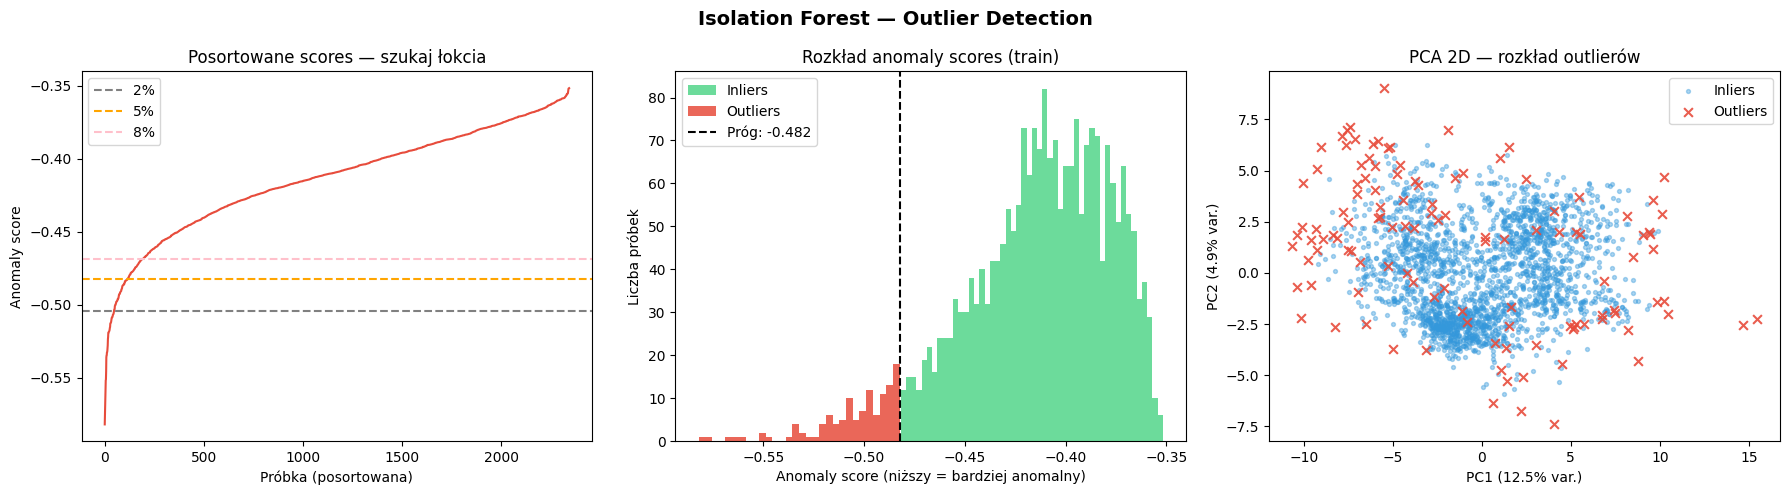

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Isolation Forest — Outlier Detection", fontsize=14, fontweight='bold')

# Elbow method for contamination
scores = iso.score_samples(X_y_combined)
ax = axes[0]
ax.plot(np.sort(scores), color='#e74c3c', linewidth=1.5)
ax.set_title('Posortowane scores — szukaj łokcia')
ax.set_xlabel('Próbka (posortowana)')
ax.set_ylabel('Anomaly score')
ax.axhline(np.percentile(scores, 2), color='gray',
                linestyle='--', label='2%')
ax.axhline(np.percentile(scores, 5), color='orange',
                linestyle='--', label='5%')
ax.axhline(np.percentile(scores, 8), color='pink',
                linestyle='--', label='8%')
ax.legend()

# Histogram anomaly scores
ax = axes[1]
ax.hist(train_iso_scores[~train_iso_mask], bins=50,
        color='#2ecc71', alpha=0.7, label='Inliers')
ax.hist(train_iso_scores[train_iso_mask], bins=30,
        color='#e74c3c', alpha=0.85, label='Outliers')
ax.axvline(iso.offset_, color='black', linestyle='--',
           linewidth=1.5, label=f'Próg: {iso.offset_:.3f}')
ax.set_title('Rozkład anomaly scores (train)')
ax.set_xlabel('Anomaly score (niższy = bardziej anomalny)')
ax.set_ylabel('Liczba próbek')
ax.legend()

# PCA 2D scatter
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(StandardScaler().fit_transform(X_train))

ax = axes[2]
ax.scatter(X_2d[~train_iso_mask, 0], X_2d[~train_iso_mask, 1],
           s=8, alpha=0.4, color='#3498db', label='Inliers')
ax.scatter(X_2d[train_iso_mask, 0], X_2d[train_iso_mask, 1],
           s=40, alpha=0.9, color='#e74c3c', marker='x',
           linewidths=1.5, label='Outliers')
ax.set_title('PCA 2D — rozkład outlierów')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)')
ax.legend()

plt.tight_layout()
plt.show()

X_train_clean = X_train[~train_iso_mask]
y_train_clean = y_train[~train_iso_mask]
X_test_clean = X_test
y_test_clean = y_test

In [8]:
scaler = StandardScaler()
X_train_clean_scaled = scaler.fit_transform(X_train_clean)
X_test_clean_scaled  = scaler.transform(X_test_clean)

print(f"X_train_clean: {X_train_clean_scaled.shape}")
print(f"X_test_clean:  {X_test_clean_scaled.shape}")
print(f"y_train_clean: {y_train_clean.shape}")
print(f"y_test_clean:  {y_test_clean.shape}")

X_train_clean: (2226, 115)
X_test_clean:  (586, 115)
y_train_clean: (2226,)
y_test_clean:  (586,)


# Wizualizacja danych

* Rozkład ceny (y) — histogram + log-transform
* Macierz korelacji (top 20)
* Wykresy 3D (6 sztuk)
* PCA / t-SNE / UMAP w 2D (kolorowane ceną)

## 1. Rozkład ceny (SalePrice)

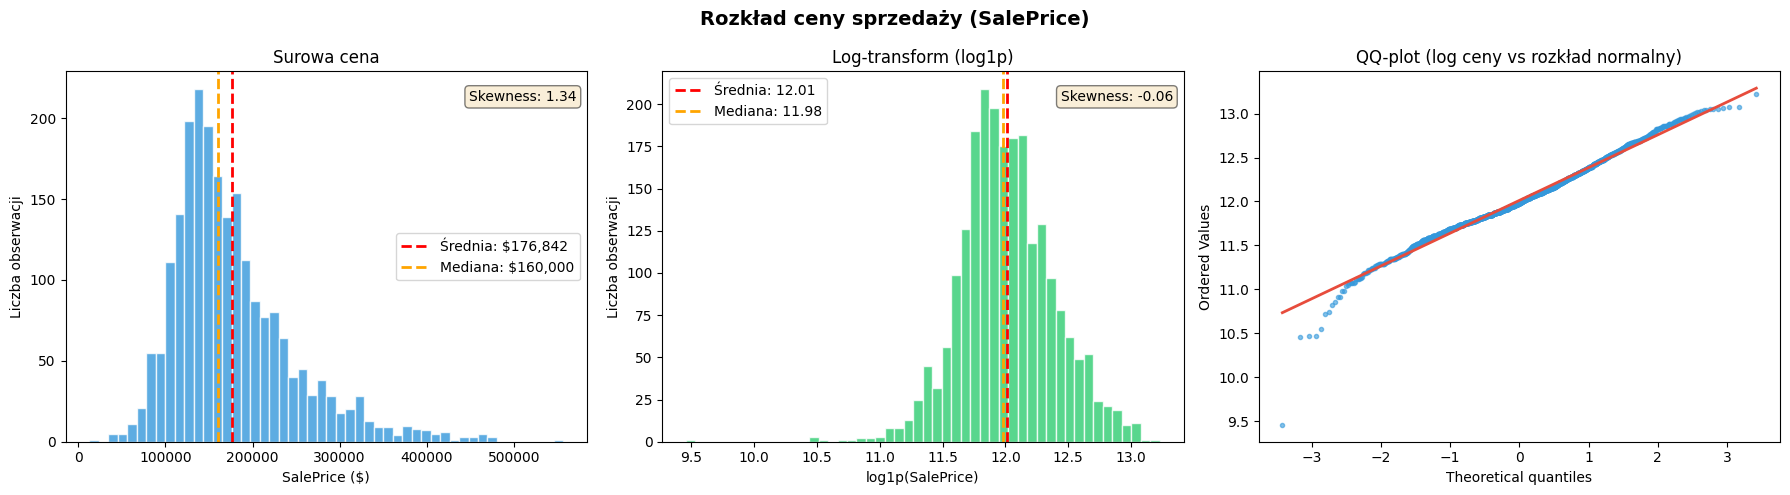

In [9]:
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Rozkład ceny sprzedaży (SalePrice)', fontsize=14, fontweight='bold')

y_all = y_train_clean  # używamy czystych danych treningowych

# Histogram surowej ceny
ax = axes[0]
ax.hist(y_all, bins=50, color='#3498db', alpha=0.8, edgecolor='white')
ax.axvline(y_all.mean(), color='red', linestyle='--', linewidth=2, label=f'Średnia: ${y_all.mean():,.0f}')
ax.axvline(y_all.median(), color='orange', linestyle='--', linewidth=2, label=f'Mediana: ${y_all.median():,.0f}')
ax.set_title('Surowa cena')
ax.set_xlabel('SalePrice ($)')
ax.set_ylabel('Liczba obserwacji')
ax.legend()
skew_val = stats.skew(y_all)
ax.text(0.98, 0.95, f'Skewness: {skew_val:.2f}', transform=ax.transAxes,
        ha='right', va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Log-transform
y_log = np.log1p(y_all)
ax = axes[1]
ax.hist(y_log, bins=50, color='#2ecc71', alpha=0.8, edgecolor='white')
ax.axvline(y_log.mean(), color='red', linestyle='--', linewidth=2, label=f'Średnia: {y_log.mean():.2f}')
ax.axvline(y_log.median(), color='orange', linestyle='--', linewidth=2, label=f'Mediana: {y_log.median():.2f}')
ax.set_title('Log-transform (log1p)')
ax.set_xlabel('log1p(SalePrice)')
ax.set_ylabel('Liczba obserwacji')
ax.legend()
skew_log = stats.skew(y_log)
ax.text(0.98, 0.95, f'Skewness: {skew_log:.2f}', transform=ax.transAxes,
        ha='right', va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# QQ-plot
ax = axes[2]
stats.probplot(y_log, dist='norm', plot=ax)
ax.set_title('QQ-plot (log ceny vs rozkład normalny)')
ax.get_lines()[0].set(color='#3498db', alpha=0.6, markersize=3)
ax.get_lines()[1].set(color='#e74c3c', linewidth=2)

plt.tight_layout()
plt.show()

## 2. Macierz korelacji (Top 20 cech)

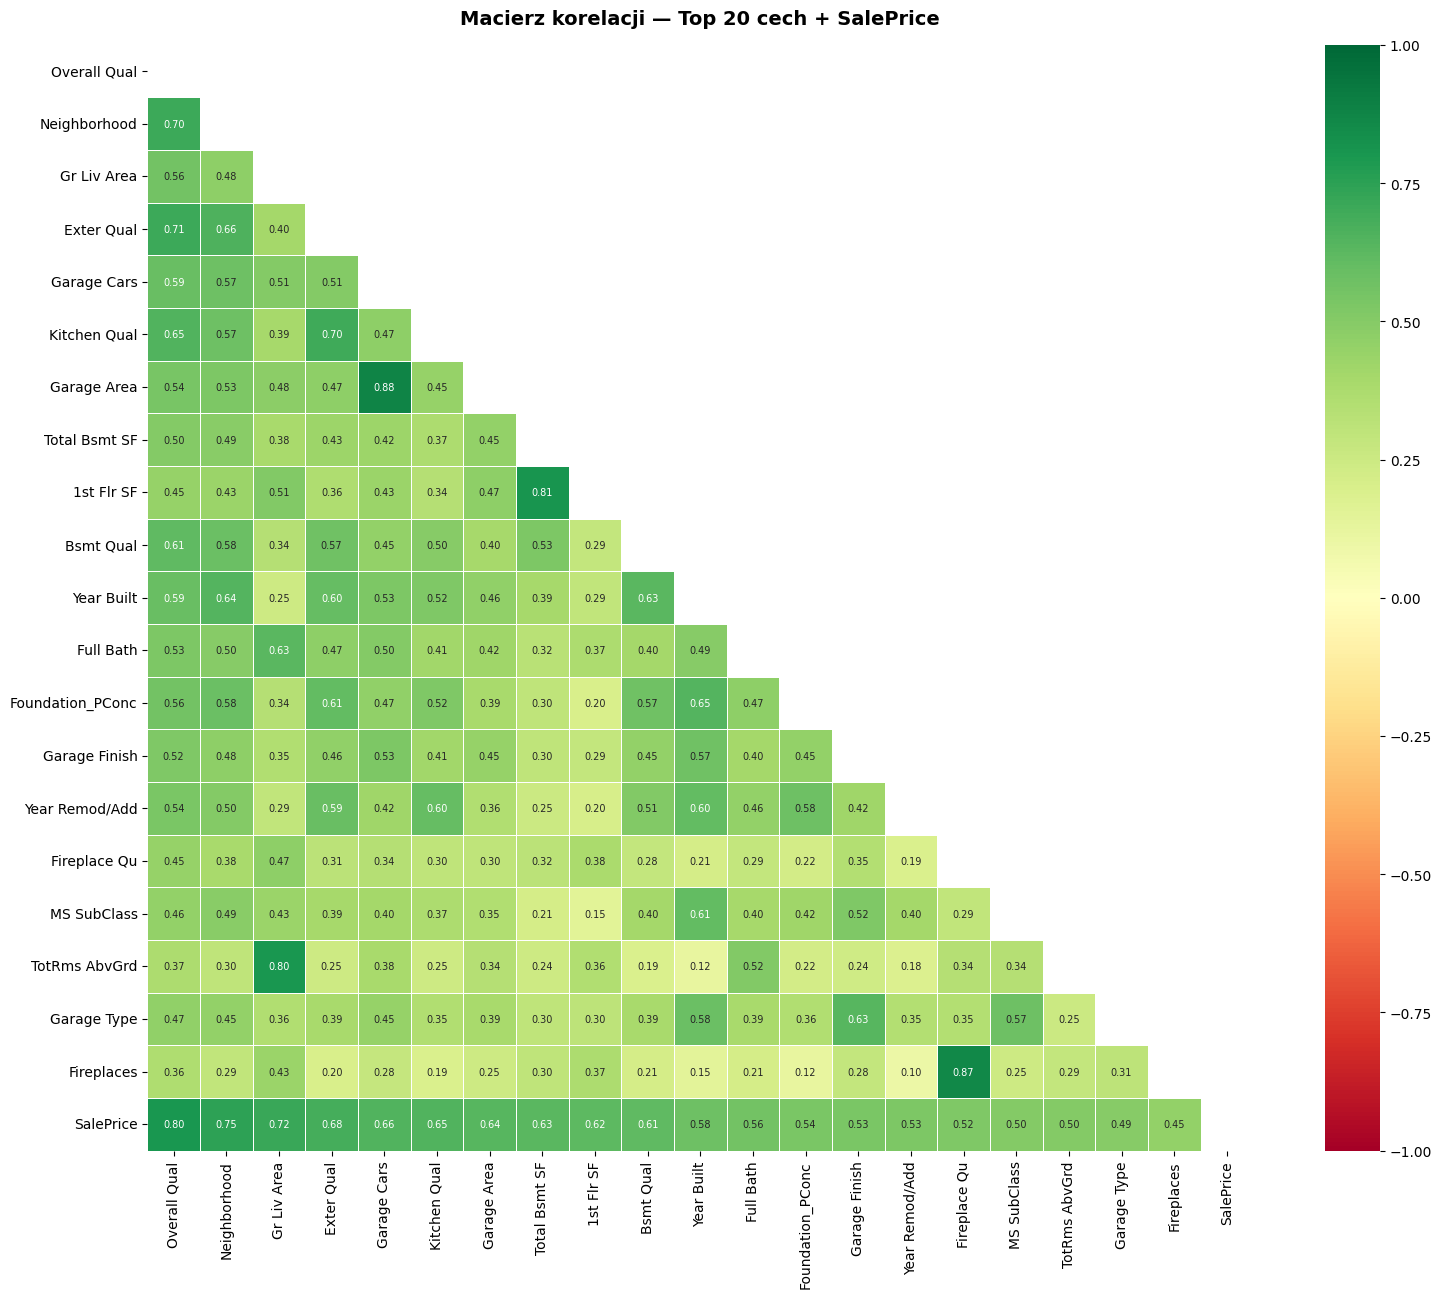

In [10]:
import seaborn as sns

# Budujemy DataFrame z oryginalnych (niestandardyzowanych) kolumn + cena
# X_train_clean to pandas DataFrame przed skalowaniem
df_analysis = X_train_clean.copy()
df_analysis['SalePrice'] = y_train_clean.values

# Korelacja Pearsona z ceną
corr_with_price = df_analysis.corr()['SalePrice'].drop('SalePrice')
top20 = corr_with_price.abs().nlargest(20).index.tolist()
top20_corr = corr_with_price[top20].sort_values(ascending=True)
top20_sorted = corr_with_price.abs().nlargest(20).index.tolist()
cols_for_corr = top20_sorted + ['SalePrice']
corr_matrix = df_analysis[cols_for_corr].corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # tylko dolny trójkąt

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 7}
)

ax.set_title('Macierz korelacji — Top 20 cech + SalePrice', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 3. Wykresy 3D — dwie cechy × cena

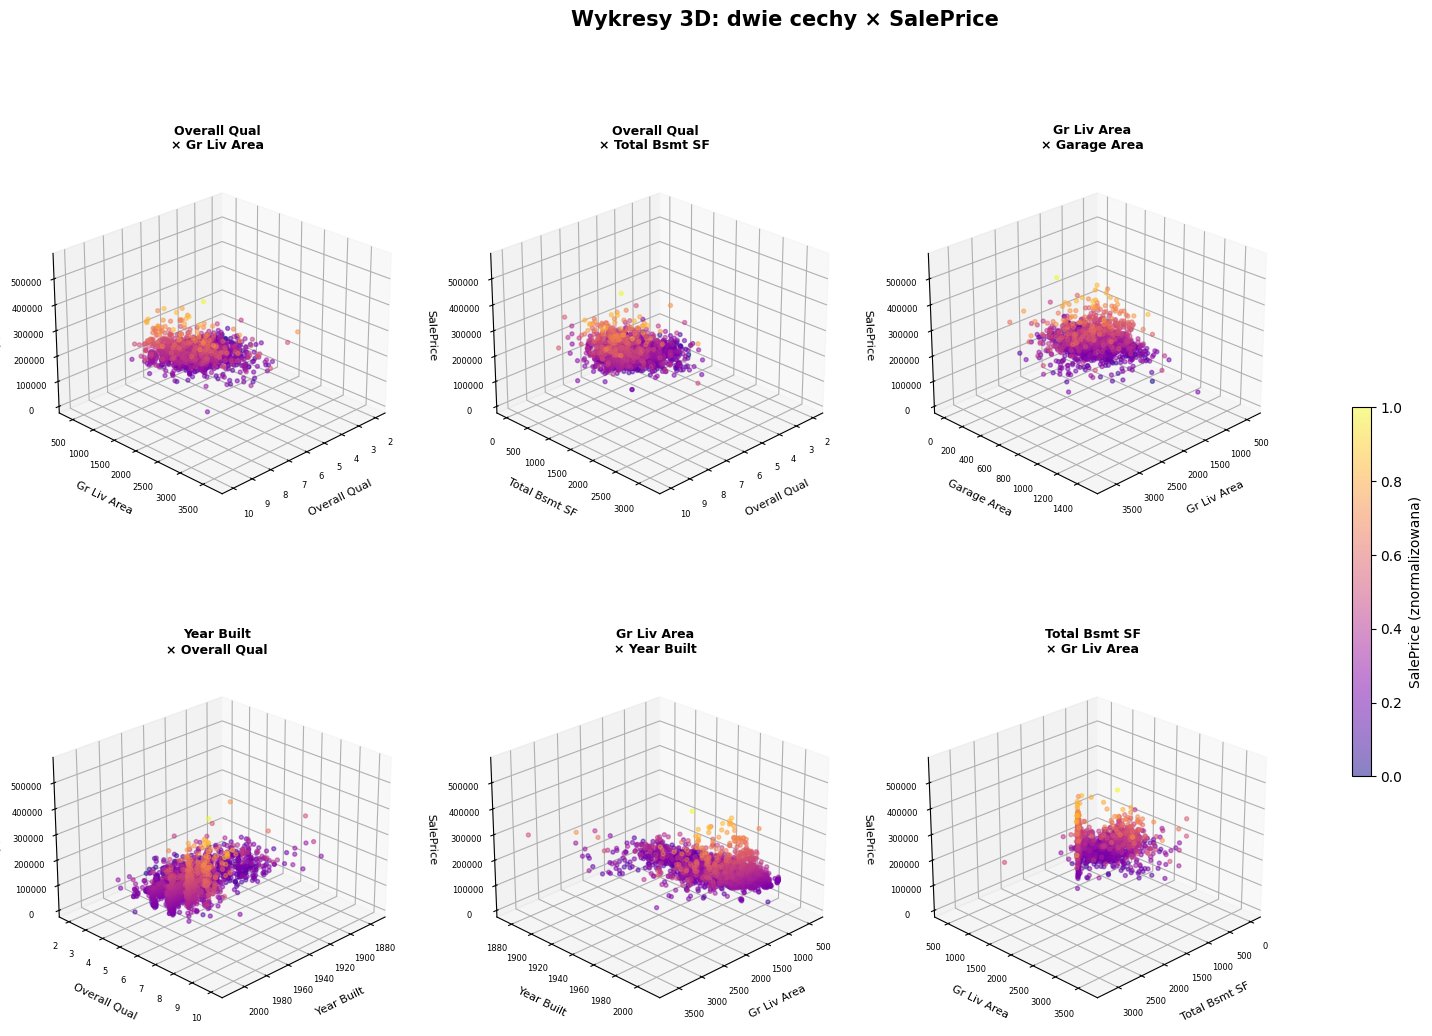

In [11]:
from mpl_toolkits.mplot3d import Axes3D

# 6 par cech (wybrane spośród top korelacji)
feature_pairs = [
    ('Overall Qual', 'Gr Liv Area'),
    ('Overall Qual', 'Total Bsmt SF'),
    ('Gr Liv Area',  'Garage Area'),
    ('Year Built',   'Overall Qual'),
    ('Gr Liv Area',  'Year Built'),
    ('Total Bsmt SF','Gr Liv Area'),
]

# Sprawdzamy które cechy istnieją w df_analysis
available = df_analysis.columns.tolist()
feature_pairs = [(a, b) for a, b in feature_pairs if a in available and b in available]

fig = plt.figure(figsize=(20, 12))
fig.suptitle('Wykresy 3D: dwie cechy × SalePrice', fontsize=15, fontweight='bold')

price = df_analysis['SalePrice'].values
price_norm = (price - price.min()) / (price.max() - price.min())  # normalizacja do koloru

for idx, (feat_x, feat_y) in enumerate(feature_pairs[:6]):
    ax = fig.add_subplot(2, 3, idx + 1, projection='3d')
    
    x = df_analysis[feat_x].values
    y = df_analysis[feat_y].values
    z = price
    
    sc = ax.scatter(x, y, z, c=price_norm, cmap='plasma', s=8, alpha=0.5)
    ax.set_xlabel(feat_x, fontsize=8, labelpad=5)
    ax.set_ylabel(feat_y, fontsize=8, labelpad=5)
    ax.set_zlabel('SalePrice', fontsize=8, labelpad=5)
    ax.set_title(f'{feat_x}\n× {feat_y}', fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=6)
    ax.view_init(elev=25, azim=45)

plt.colorbar(sc, ax=fig.axes, label='SalePrice (znormalizowana)', shrink=0.4, pad=0.05)
# plt.tight_layout()
plt.show()

## 4. Redukcja wymiarów do 2D: PCA / t-SNE / UMAP (kolorowane ceną)

c:\Users\Staszek\Documents\GitHub\flat-price\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


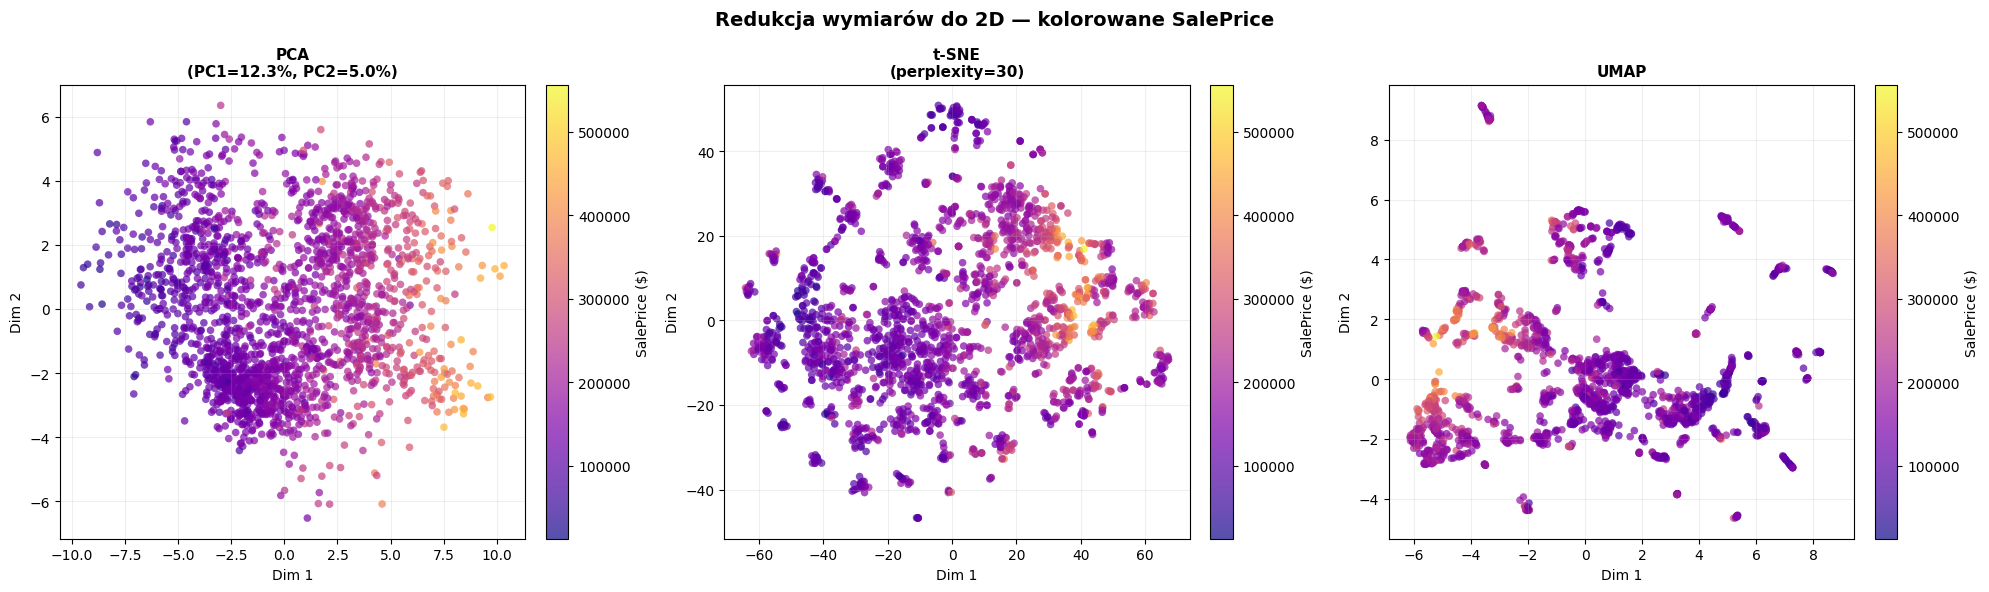

In [34]:
from sklearn.manifold import TSNE
import umap

np.random.seed(42)
n_sample = min(2000, X_train_clean_scaled.shape[0])
idx_sample = np.random.choice(X_train_clean_scaled.shape[0], n_sample, replace=False)
X_sample = X_train_clean_scaled[idx_sample]
y_sample = y_train_clean.values[idx_sample]

pca2 = PCA(n_components=2, random_state=42)
X_pca = pca2.fit_transform(X_sample)

tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000, verbose=0)
X_tsne = tsne.fit_transform(X_sample)

reducer = umap.UMAP(n_components=2, random_state=42, verbose=False)
X_umap = reducer.fit_transform(X_sample)
umap_available = True

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Redukcja wymiarów do 2D — kolorowane SalePrice', fontsize=14, fontweight='bold')

datasets = [
    (X_pca,  f'PCA\n(PC1={pca2.explained_variance_ratio_[0]*100:.1f}%, PC2={pca2.explained_variance_ratio_[1]*100:.1f}%)'),
    (X_tsne, 't-SNE\n(perplexity=30)'),
    (X_umap, 'UMAP' if umap_available else 'Kernel PCA (rbf)\n[UMAP nie zainstalowany]'),
]

for ax, (X_2d, title) in zip(axes, datasets):
    sc = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y_sample,
                    cmap='plasma', s=30, alpha=0.7, edgecolors='none')
    plt.colorbar(sc, ax=ax, label='SalePrice ($)', fraction=0.046, pad=0.04)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Dim 1')
    ax.set_ylabel('Dim 2')
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# Modele

1. Regresja liniowa
   - zwykła
   - metryki (mse, r^2)
   - wykresy działania - Predicted vs Actual, Residuals vs Fitted, top features coeficiency
   
2. Drzewo decyzyjne 
    - opytmalizacja parametrów (GridSearchCV - max_depth, min_samples_split, min_samples_leaf, max_features, ccp_alpha (pruning))
    -  metryki (MSE, R²)
    -  wykresy działania - Wizualizacja drzewa (plot_tree), Feature importance (bar), Depth vs MSE (krzywa), Predicted vs Actual
  
3. Regresja wielomianowa 
   - wybor 20 best cech (korelacja z ceną, RFE, SelectKBest)
   - opytmalizacja parametrów - degree
   - regularyzacja
   - metryki (MSE, R², Adjusted R²)
   - wykresy działania (Predicted vs Actual, Residuals vs Fitted, Degree vs MSE (train/val))


                      RMSE         MAE        R²      Adj R²
Linear Regresion      31576      18460   0.8756     0.8452


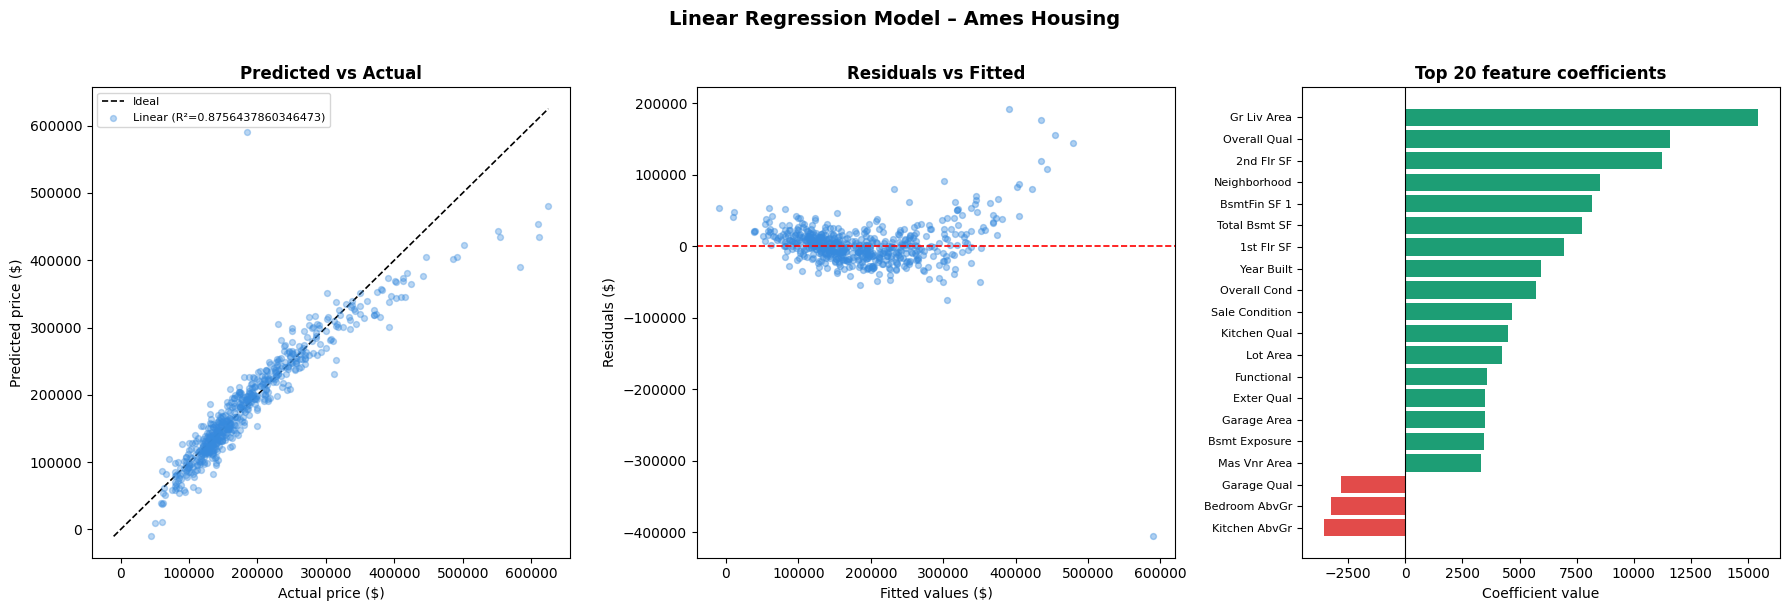

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

reg = LinearRegression()
reg.fit(X_train_clean_scaled, y_train_clean)
reg_y_pred = reg.predict(X_test_clean_scaled)

# Metrics
n_test = len(y_test_clean)
n_features = X_test_clean_scaled.shape[1]

def adj_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

mse  = mean_squared_error(y_test_clean, reg_y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test_clean, reg_y_pred)
r2   = r2_score(y_test_clean, reg_y_pred)
ar2  = adj_r2(r2, n_test, n_features)
print(f"\n                {'RMSE':>10}  {'MAE':>10}  {'R²':>8}  {'Adj R²':>10}")
print(f"Linear Regresion {rmse:>10.0f} {mae:>10.0f} {r2:>8.4f} {ar2:>10.4f}")

# Plots
fig = plt.figure(figsize=(18, 6))

# ── Wykres 1: Predicted vs Actual
ax1 = fig.add_subplot(131)
y_min = min(y_test_clean.min(), reg_y_pred.min())
y_max = max(y_test_clean.max(), reg_y_pred.max())
ax1.plot([y_min, y_max], [y_min, y_max], 'k--', lw=1.2, label='Ideal', zorder=1)
ax1.scatter(y_test_clean, reg_y_pred, alpha=0.35, s=18, color='#378ADD', label=f"Linear (R²={r2})", zorder=2)
ax1.set_xlabel('Actual price ($)')
ax1.set_ylabel('Predicted price ($)')
ax1.set_title('Predicted vs Actual', fontweight='bold')
ax1.legend(fontsize=8)

# ── Wykres 2: Residuals vs Fitted
ax2 = fig.add_subplot(132)
residuals = y_test_clean - reg_y_pred
ax2.axhline(0, color='red', lw=1.2, ls='--')
ax2.scatter(reg_y_pred, residuals, alpha=0.4, s=18, color='#378ADD')
ax2.set_xlabel('Fitted values ($)')
ax2.set_ylabel('Residuals ($)')
ax2.set_title(f'Residuals vs Fitted', fontweight='bold')

# ── Wykres 3: Top-20 feature importance
ax3 = fig.add_subplot(133)
coefs = pd.Series(reg.coef_, index=df_analysis.columns[:-1])
top20 = coefs.abs().nlargest(20).index
coefs_top = coefs[top20].sort_values()
bar_colors = ['#1D9E75' if v > 0 else '#E24B4A' for v in coefs_top]
ax3.barh(coefs_top.index, coefs_top.values, color=bar_colors)
ax3.axvline(0, color='black', lw=0.8)
ax3.set_title('Top 20 feature coefficients', fontweight='bold')
ax3.set_xlabel('Coefficient value')
ax3.tick_params(axis='y', labelsize=8)

plt.suptitle('Linear Regression Model – Ames Housing', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

parameters = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 10, 20, 50],
    'min_samples_leaf': [1, 3, 5, 10],
    'max_features': [None, 'sqrt', 'log2'],
    'ccp_alpha': [0.0, 0.001, 0.01, 0.05] 
}

clf = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid=parameters,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1
)
clf.fit(X_train_clean_scaled, y_train_clean)
print(f"Tree best params: {clf.best_params_}")

dt = clf.best_estimator_
dt_y_pred = dt.predict(X_test_clean_scaled)

mse  = mean_squared_error(y_test_clean, dt_y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test_clean, dt_y_pred)
r2   = r2_score(y_test_clean, dt_y_pred)
print(f"\n              {'RMSE':>10}  {'MAE':>10}  {'R²':>8}")
print(f"Decision Tree {rmse:>10.0f} {mae:>10.0f} {r2:>8.4f}")


Tree best params: {'ccp_alpha': 0.0, 'max_depth': 15, 'max_features': None, 'min_samples_leaf': 10, 'min_samples_split': 2}

                  RMSE         MAE        R²
Decision Tree      34017      22342   0.8557


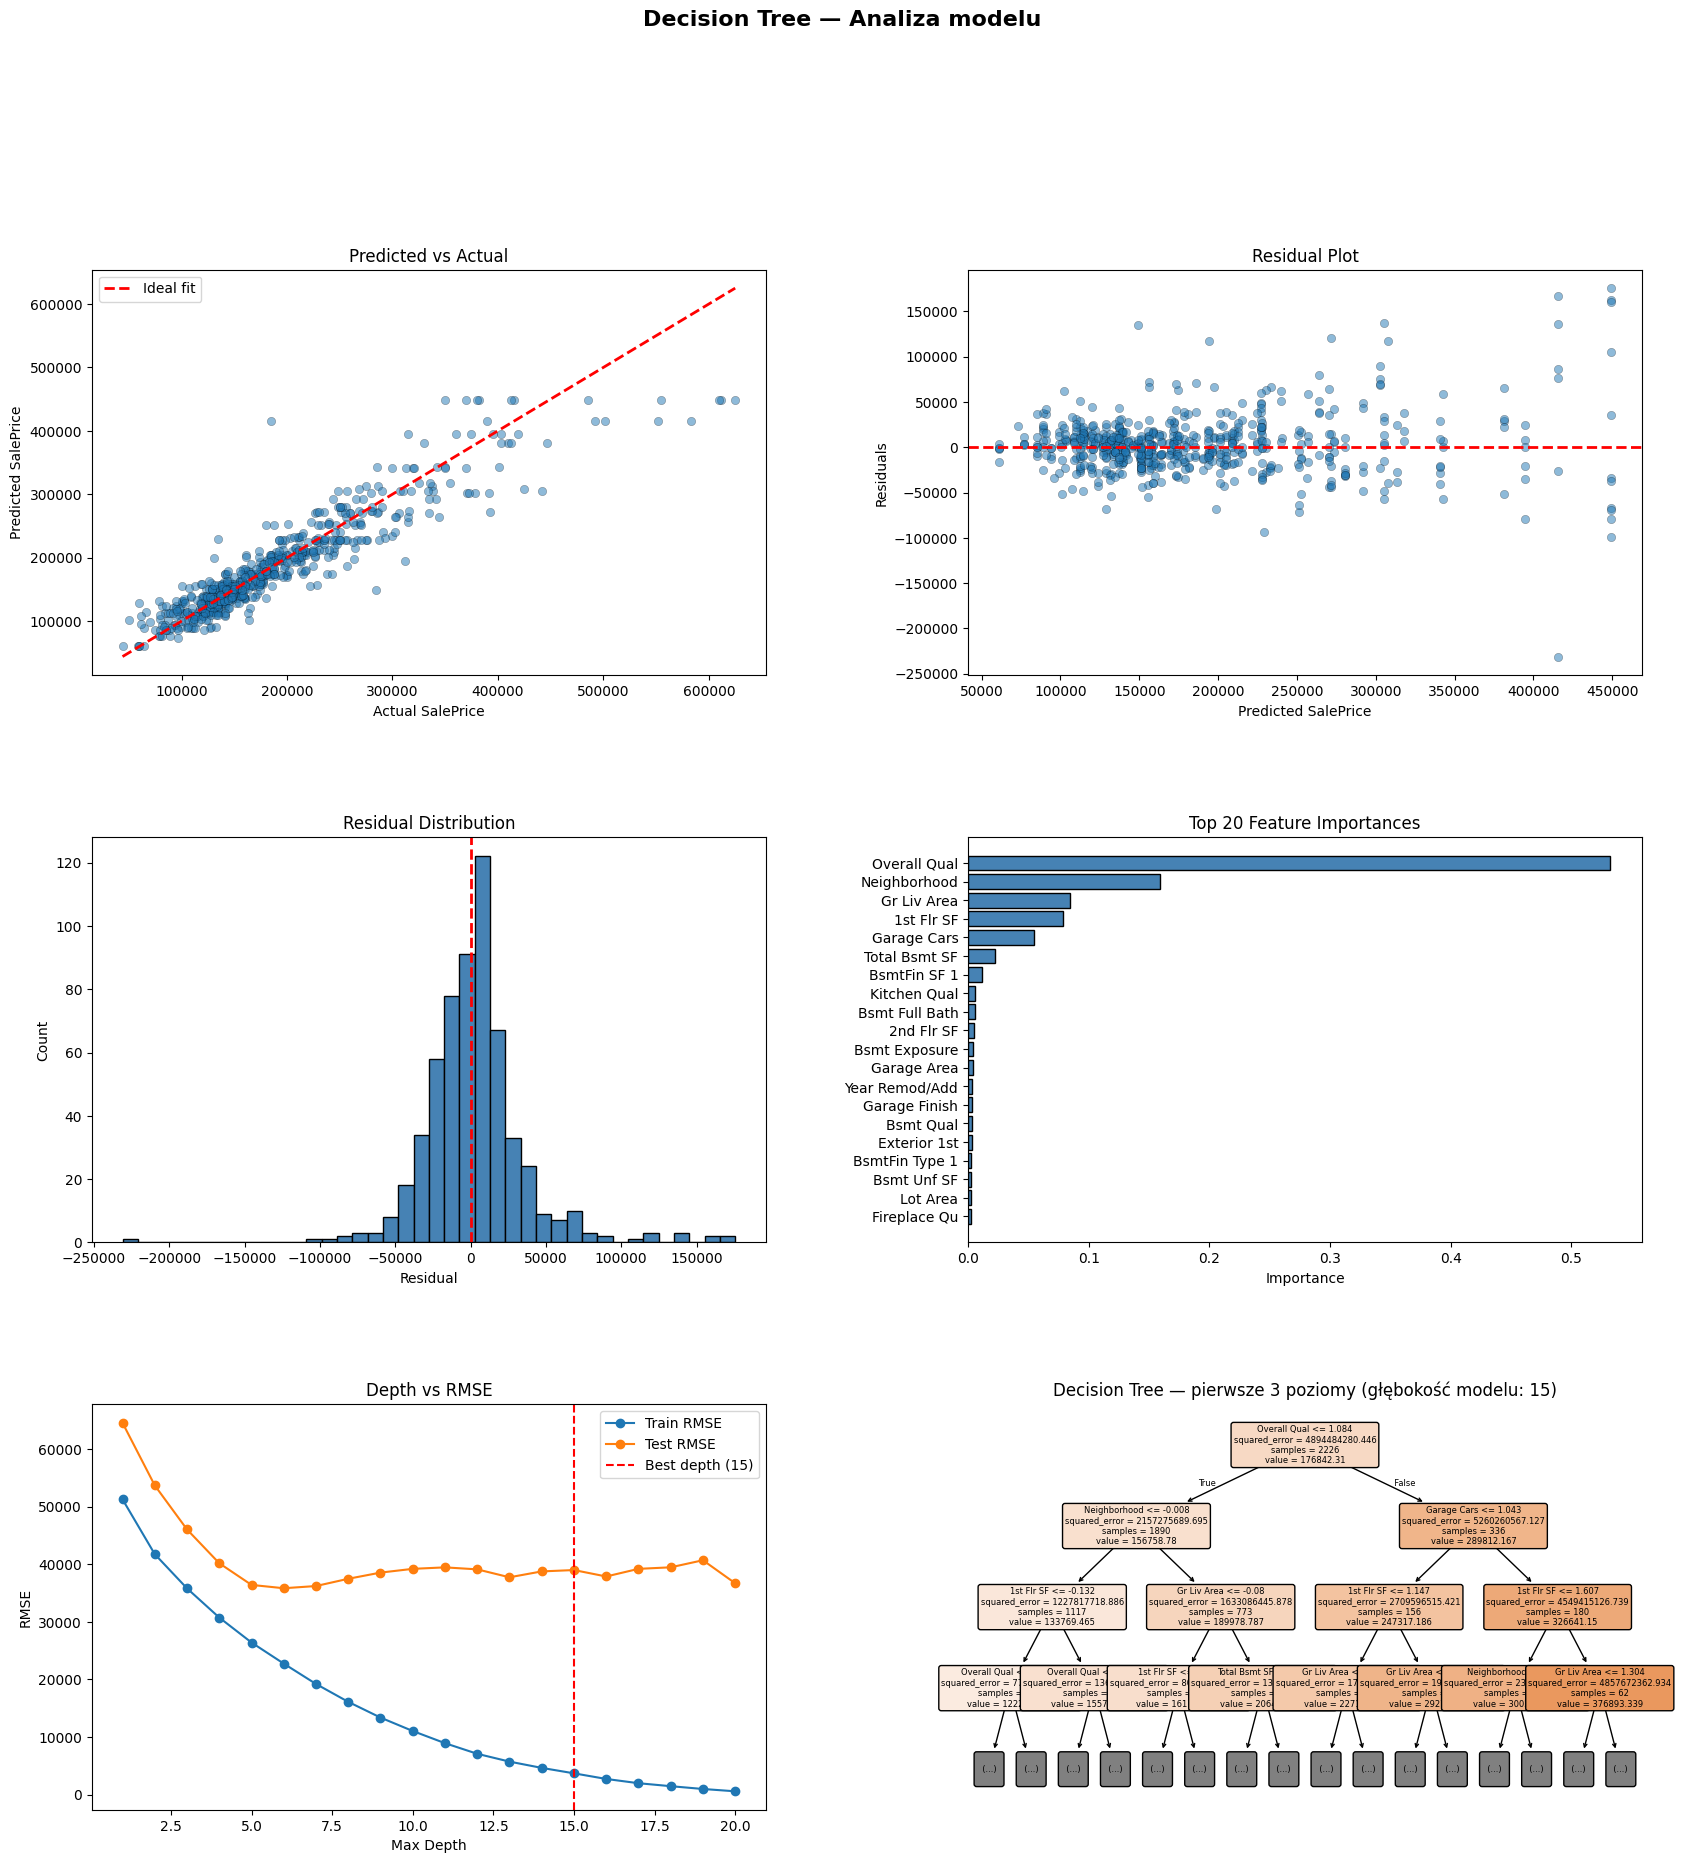

In [43]:
import matplotlib.gridspec as gridspec
from sklearn.tree import plot_tree

residuals = y_test_clean - dt_y_pred

fig = plt.figure(figsize=(20, 20))
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.3)

# ── 1. Predicted vs Actual ──────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(y_test_clean, dt_y_pred, alpha=0.5, edgecolors='k', linewidths=0.3)
min_val = min(y_test_clean.min(), dt_y_pred.min())
max_val = max(y_test_clean.max(), dt_y_pred.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal fit')
ax1.set_xlabel("Actual SalePrice")
ax1.set_ylabel("Predicted SalePrice")
ax1.set_title("Predicted vs Actual")
ax1.legend()

# ── 2. Residual Plot ────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(dt_y_pred, residuals, alpha=0.5, edgecolors='k', linewidths=0.3)
ax2.axhline(0, color='red', linestyle='--', lw=2)
ax2.set_xlabel("Predicted SalePrice")
ax2.set_ylabel("Residuals")
ax2.set_title("Residual Plot")

# ── 3. Residual Distribution ────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(residuals, bins=40, edgecolor='black', color='steelblue')
ax3.axvline(0, color='red', linestyle='--', lw=2)
ax3.set_xlabel("Residual")
ax3.set_ylabel("Count")
ax3.set_title("Residual Distribution")

# ── 4. Feature Importance (Top 20) ─────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
importances = dt.feature_importances_
feature_names = df_analysis.columns.to_list()
indices = np.argsort(importances)[::-1][:20]
ax4.barh(
    [feature_names[i] for i in indices[::-1]],
    importances[indices[::-1]],
    color='steelblue', edgecolor='black'
)
ax4.set_xlabel("Importance")
ax4.set_title("Top 20 Feature Importances")

# ── 5. Depth vs RMSE ────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
depths = range(1, 21)
train_rmses, test_rmses = [], []
for d in depths:
    tmp = DecisionTreeRegressor(max_depth=d, random_state=42)
    tmp.fit(X_train_clean_scaled, y_train_clean)
    train_rmses.append(np.sqrt(mean_squared_error(y_train_clean, tmp.predict(X_train_clean_scaled))))
    test_rmses.append(np.sqrt(mean_squared_error(y_test_clean,  tmp.predict(X_test_clean_scaled))))

ax5.plot(depths, train_rmses, 'o-', label='Train RMSE')
ax5.plot(depths, test_rmses,  'o-', label='Test RMSE')
ax5.axvline(dt.get_depth(), color='red', linestyle='--', label=f'Best depth ({dt.get_depth()})')
ax5.set_xlabel("Max Depth")
ax5.set_ylabel("RMSE")
ax5.set_title("Depth vs RMSE")
ax5.legend()

# ── 6. Tree Visualization ───────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
plot_tree(
    dt,
    max_depth=3,
    feature_names=df_analysis.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=6,
    ax=ax6
)
ax6.set_title(f"Decision Tree — pierwsze 3 poziomy (głębokość modelu: {dt.get_depth()})")

plt.suptitle("Decision Tree — Analiza modelu", fontsize=16, fontweight='bold', y=1.01)
plt.savefig("decision_tree_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

# add log1 to prices